<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.2 Transformação de tensões. Tensões principais. Direções principais.

## Problema 4 <a name="PI24"></a>

Considere o seguinte estado de tensão $\sigma_{ji}$ (MPa)

\begin{equation*}
\sigma_{ji} =
\begin{bmatrix}
6 & 4 & 0 \\
4  & 0 & 0 \\
0 & 0 & 4
\end{bmatrix}
\end{equation*}

[a)](#A) Determine o vetor tensão atuando numa faceta cuja normal é definida pelo vector $\vec{n} = 1/2 \,\vec{\imath} - 1/2 \,\vec{\jmath} + 1/\sqrt{2}\,\vec{k}$.

[b)](#B) Indique as componentes normal e de corte do vetor tensão e determine o ângulo entre o vetor tensão e a normal à faceta definida por $\vec{n}$.

[c)](#C) Determine as tensões principais.

[d)](#D) Verifique o resultado da alínea anterior pelo método dos invariantes.

[e)](#E) Determine a 1ª direcção principal.


## Resolução

#### a) Determine o vetor tensão atuando numa faceta cuja normal é definida pelo vector $\vec{n} = 1/2 \,\vec{\imath} - 1/2 \,\vec{\jmath} + 1/\sqrt{2}\,\vec{k}$. <a name="A"></a>
([enunciatum](#PI24))

Matriz das tensões num dado sistema de coordenadas:
 Sji = 
 [[6 4 0]
 [4 0 0]
 [0 0 4]]

Versor n1, normal a faceta no ponto P onde atua o vetor tensao:
n1 =  [ 0.500 -0.500  0.707]
||n1|| = 1.0

Componente do vetor tensao em relacao a n1:
tb1 =  [ 1.000  2.000  2.828]


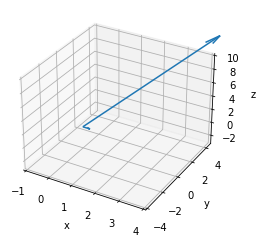

In [1]:
import numpy as np
np.set_printoptions(formatter={'float': '{: 0.3f}'.format})

def matrizTensoes(sxx,sxy,sxz,syy,syz,szz):
    return np.array([[sxx,sxy,sxz],[sxy,syy,syz],[sxz,syz,szz]])

sij = matrizTensoes(6,4,0,0,0,4)
print('Matriz das tensões num dado sistema de coordenadas:\n Sji = \n', sij)

def versor(v1,v2,v3): return np.array([v1,v2,v3])

n1 = versor(1/2,-1/2,1/np.sqrt(2))
print('\nVersor n1, normal a faceta no ponto P onde atua o vetor tensao:')
print('n1 = ', n1)

norman1 = np.linalg.norm(n1)
print(f'||n1|| = {norman1:.1f}')

tn1 = np.dot(n1,sij)
print('\nComponente do vetor tensao em relacao a n1:')
print('tb1 = ', tn1)

# PLOT 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

lis1 = [0,0,0,n1[0],n1[1],n1[2]]
lis2 = [0,0,0,tn1[0], tn1[1],tn1[2]]
setas = np.array( [lis1,lis2])
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i in setas:
    v = np.array([i[3],i[4],i[5]])
    vlength = np.linalg.norm(v)
    ax.quiver(i[0],i[1],i[2],i[3],i[4],i[5],
            pivot='tail',length=vlength,arrow_length_ratio=0.3/vlength)
ax.set_xlim([-1.,4.])
ax.set_ylim([-4.,4.5])
ax.set_zlim([-3,10])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

#### b) Indique as componentes normal e de corte do vetor tensão e determine o ângulo entre o vetor tensão e a normal à faceta definida por $\vec{n}$.<a name="B"></a>

([enunciatum](#PI24))

A componente normal do vetor das tensões é dada por:

\begin{equation*}
\sigma_n = \underbrace{\vec{t}^{(\vec{n})}\cdot \vec{n}}_{\textrm{vetorial}} =
\underbrace{t_i \cdot n_i}_{\textrm{indicial}} =
\underbrace{\underline{t}^{T} \underline{n}}_{\textrm{matricial}}
\end{equation*}

A componente de corte do das tensões vem:

\begin{equation*}
\tau = (||\vec{t}^{(\vec{n})}||^2 - \sigma_n^2)^{1/2} = (\vec{t}^{(\vec{n})}\cdot\vec{t}^{(\vec{n})} -
\sigma_n^2)^{1/2} = (t_1^2+ t_2^2 + t_3^2 - \sigma_n^2)^{1/2}
\end{equation*}

A ângulo, $\theta$, entre o vetor tensão, $\vec{t}^{(\vec{n})}$, e a normal à faceta definida por $\vec{n}$ pode ser obtido por

\begin{equation*}
\cos\theta = \frac{\vec{t}^{(\vec{n})} \cdot \vec{\sigma}_n}{||\vec{t}^{(\vec{n})}||\cdot||\vec{\sigma}_n||}
= \frac{\vec{t}^{(\vec{n})} \cdot
\vec{n}}{\sqrt{\vec{t}^{(\vec{n})}\cdot\vec{t}^{(\vec{n})}}}
\end{equation*}

em que,

\begin{equation*}
\vec{\sigma}_n = \sigma_n \vec{n} = 1/2\sigma_n \vec{e}_1 - 1/2\sigma_n \vec{e}_2 + 1/\sqrt{2}\sigma_n \vec{e}_3
\end{equation*}

ou

\begin{equation*}
\tan\theta = \frac{\tau}{\sigma_n}
\end{equation*}

In [2]:
Sign = np.dot(tn1,n1)
print('Tensao normal: \n','{:.2f}'.format(Sign))

Taut = (tn1[0]*tn1[0] + tn1[1]*tn1[1] + tn1[2]*tn1[2] - Sign**2)**(1/2)
print('Tensao de corte (versao 1): \n','{:.2f}'.format(Taut))

Taut_v2 = np.sqrt(np.dot(tn1,tn1) - Sign**2)
print('Tensao de corte (versao 2) : \n','{:.2f}'.format(Taut_v2))

print('\n')
vA = Sign*n1
print('vA (= Sign*n1) :',vA)
vB = tn1
print('    vB (= tn1) :',vB)
num = np.dot(vA,vB)
print('         vA.vB :','{:.2f}'.format(num))
den = np.sqrt(np.dot(vA,vA))*np.sqrt(np.dot(vB,vB))
print(' ||vA||.||vB|| :','{:.2f}'.format(den))
angtn1 = num/den
print('Angulo entre vetor tensao e normal a faceta : \n')
print('ang (= arccos(vA.vB/||vA||.||vB||)) :','{:.2f}'.format(np.rad2deg(np.arccos(angtn1))),' graus')

print('\n em alternativa : \n')
print('ang (= arctan(Tau/Sign) :','{:.2f}'.format(np.rad2deg(np.arctan(Taut/Sign))),' graus')

Tensao normal: 
 1.50
Tensao de corte (versao 1): 
 3.28
Tensao de corte (versao 2) : 
 3.28


vA (= Sign*n1) : [ 0.750 -0.750  1.061]
    vB (= tn1) : [ 1.000  2.000  2.828]
         vA.vB : 2.25
 ||vA||.||vB|| : 5.41
Angulo entre vetor tensao e normal a faceta : 

ang (= arccos(vA.vB/||vA||.||vB||)) : 65.42  graus

 em alternativa : 

ang (= arctan(Tau/Sign) : 65.42  graus


#### c) Determine as tensões principais.<a name="C"></a>
([enunciatum](#PI24))

Como $\{t\}^{(\vec{k})} = [\sigma] \{k\} = \sigma_{zz} \vec{k}$ conclui-se diretamente que $\sigma_{zz}$ é tensão principal e que $\vec{k}$ é vetor principal. Como $\sigma_{zz} = 4$ MPa, este valor é uma das raízes reais da equação característica.

\begin{equation*}
\begin{vmatrix}
\sigma_{xx}-\sigma& \sigma_{xy} & \sigma_{xz} \\
\sigma_{yx} & \sigma_{yy} -\sigma & \sigma_{yz} \\
\sigma_{zx} & \sigma_{zy} & \sigma_{zz}-\sigma
\end{vmatrix} =
\begin{vmatrix}
6-\sigma  & 4 & 0 \\
4 & -\sigma & 0 \\
0 & 0 & 4-\sigma
\end{vmatrix} = 0
\end{equation*}

\begin{equation*}
(6-\sigma)
\begin{vmatrix}
-\sigma & 0 \\
0 & 4-\sigma
\end{vmatrix} + 4
\begin{vmatrix}
0 & 4 \\
4-\sigma &   0
\end{vmatrix} = 0
\end{equation*}

\begin{equation*}
(6-\sigma)(-\sigma)(4-\sigma)
-16 (4-\sigma) = (4-\sigma)(\sigma^2 - 6 \sigma - 16) = 0
\end{equation*}

De notar que uma vez que a terceira direção do eixo $z$ é uma direção
principal ($\tau_{3\beta} = 0~, \beta = 1,2$) poder-se-ia escrever diretamente:

\begin{equation*}
\begin{aligned}
(4-\sigma)
\begin{vmatrix}
6-\sigma & 4 \\
4 & -\sigma
\end{vmatrix} = (4-\sigma)(\sigma^2 - 6 \sigma - 16) = 0
\end{aligned}
\end{equation*}

em que o cálculo se resume a um determinante $2\times2$.

Pelo que se conclui:

\begin{equation*}
4-\sigma  = 0  \quad\vee\quad
\sigma^2 - 6 \sigma - 16 = 0
\end{equation*}

Atendendo à fórmula resolvente quadrática:

\begin{equation*}
\sigma = \frac{-b\pm\sqrt{b^2 - 4ac}}{2a} =
\frac{6\pm\sqrt{36 - 4(1)(-16)}}{2(1)}
\end{equation*}

In [3]:
def fQuad(a,b,c):
    r1 = (-b + np.sqrt(b**2 - 4*a*c))/(2*a)
    r2 = (-b - np.sqrt(b**2 - 4*a*c))/(2*a)
    return r1, r2

a1 = 1
b1 = -6
c1 = -16
lambda2Q = fQuad(a1,b1,c1)
print('lambda2Q = ',lambda2Q)

lambda2Q =  (8.0, -2.0)


As raízes da equação caraterística vêm:

\begin{equation*}
(\sigma - 4)(\sigma - 8)(\sigma + 2) = 0
\end{equation*}

Pelo que os valores próprios (raízes da equação caraterística) podem ser ordenados por ordem decresente em: $\sigma_{\mathrm{I}} = 8$ MPa, $\sigma_{\mathrm{II}} = 4$ MPa e $\sigma_{\mathrm{III}} = -2$ MPa.

#### d) Verifique o resultado da alínea anterior pelo método dos invariantes.<a name="D"></a>
([enunciatum](#PI24))

A equação carateristica associada à expressão: $|\sigma_{ij}-\sigma\delta_{ij}| = 0$, é um polinómio de terceiro grau na incógnita $\sigma$:

\begin{equation*}
\sigma^3 - I_1\sigma^2 + I_2\sigma - I_3 = 0
\end{equation*}

em que $I_i$ ($i=1,2,3$) representam os invariantes do tensor das tensões assim definidos em função das componentes do tensor das tensões $\sigma_{ij}$:

\begin{equation*}
\begin{aligned}
I_1 &= \mathrm{Tr}(\sigma_{ij}) \\
I_2 &= \frac{1}{2}\left[ \mathrm{Tr}(\sigma_{ij})^2 - \mathrm{Tr}(\sigma_{ij}^2) \right] =
\frac{1}{2}\left( \sigma_{ii}\sigma_{jj} - \sigma_{ij}\sigma_{ji} \right) \\
& =
\begin{vmatrix}
\sigma_{11} & \sigma_{12} \\
\sigma_{21} & \sigma_{22} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{11} & \sigma_{13} \\
\sigma_{31} & \sigma_{33} \\
\end{vmatrix} +
\begin{vmatrix}
\sigma_{22} & \sigma_{23} \\
\sigma_{32} & \sigma_{33} \\
\end{vmatrix} \\\\
I_3 &= \mathrm{det}(\sigma_{ij}) \\
\end{aligned}
\end{equation*}

In [4]:
I1 = np.trace(sij)
print('1º Invariante, I1 :', '{:.2f}'.format(I1))

I2 = 0.5*(np.trace(sij)**2 -np.trace(np.dot(sij,sij)))
print('2º Invariante, I2 :', '{:.2f}'.format(I2))

I3 = np.linalg.det(sij)
print('2º Invariante, I3 :', '{:.2f}'.format(I3))

print('\n Resolucao Numerica - Numpy : ............................')
valProp = np.roots([1,-I1,I2,-I3])
print('\n Numpy : roots = ',valProp)
valProp = np.sort(valProp) # sort min to max
sIII = round(valProp[0])
sII = round(valProp[1])
sI = round(valProp[2])
print('\n  Tensão principal (valor próprio) sI :','{:.1f}'.format(sI))
print(' Tensão principal (valor próprio) sII :','{:.1f}'.format(sII))
print('Tensão principal (valor próprio) sIII :','{:.1f}'.format(sIII))

1º Invariante, I1 : 10.00
2º Invariante, I2 : 8.00
2º Invariante, I3 : -64.00

 Resolucao Numerica - Numpy : ............................

 Numpy : roots =  [ 8.000  4.000 -2.000]

  Tensão principal (valor próprio) sI : 8.0
 Tensão principal (valor próprio) sII : 4.0
Tensão principal (valor próprio) sIII : -2.0


Quando se usa o critério de magnitude (mas não orientação) as tensões principais são ordenadas, por convensão, por ordem descrecente: $\sigma_{\mathrm{I}} > \sigma_{\mathrm{II}} > \sigma_{\mathrm{III}}$. Neste caso, resulta: $\sigma_{\mathrm{I}} = 8$ MPa, $\sigma_{\mathrm{II}} = 4$ MPa e $\sigma_{\mathrm{III}} = -2$ MPa.

Considere-se a análise do tensor das tensões num sistema de coordenadas definido pelos eixos principais.  No sistema de coordenadas principal, $S(0,\vec{e}_\alpha,\vec{e}_\beta,,\vec{e}_\gamma)$ a fórmula de Cauchy escreve-se por (com $\vec{n}$ um versor perpendicular a uma faceta arbitrária no ponto):

\begin{equation*}
\vec{t}(\vec{n}) =
\begin{bmatrix}
t_\alpha(\vec{n}) \\
t_\beta(\vec{n}) \\
t_\gamma(\vec{n})
\end{bmatrix} =
\begin{bmatrix}
\sigma_\alpha & 0 & 0 \\
0 & \sigma_\beta & 0 \\
0  & 0 & \sigma_\gamma \\
\end{bmatrix}
\begin{bmatrix}
n_\alpha \\
n_\beta \\
n_\gamma
\end{bmatrix}
\end{equation*}

Esta expressão é equivalente a:

\begin{equation*}
t_\alpha(\vec{n}) = \sigma_\alpha n_\alpha~,\quad
t_\beta(\vec{n}) = \sigma_\beta n_\beta~,\quad
t_\gamma(\vec{n}) = \sigma_\gamma n_\gamma~
\end{equation*}

Considerando que a norma de um vetor unitário se expressa pela equação:

\begin{equation*}
n_\alpha^2 + n_\beta^2 + n_\gamma^2 = 1
\end{equation*}

resulta,

\begin{equation*}
\left(\frac{t_\alpha(\vec{n})}{\sigma_\alpha}\right)^2
\left(\frac{t_\beta(\vec{n})}{\sigma_\beta}\right)^2 +
\left(\frac{t_\gamma(\vec{n})}{\sigma_\gamma}\right)^2 = 1
\end{equation*}

Esta expressão matemática representa um elipsoide. Nesta equação, os coeficientes $\sigma_\alpha, \sigma_\beta, \sigma_\gamma$ determinam as dimensões e forma do elipsoide. Mostra-se assim que que os tensores (de segunda-ordem) simétricos podem ser representados geometricamente por elipsoides $^1$.

O caso especial em que o tensor das tensões se expressa por uma matriz diagonal (i.e. elementos nulos fora da diagonal principal, com componentes de corte nulas) ocorre quando os eixos de um sistema de coordenadas, ortonormal e direto, estão alinhados com os eixos principais do elipsoide.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au02/elipsoide.jpg" width="300" height="250">

_Fig. Representação do tensor com um elipsóide. Escolha de dois sistemas de coordenados diferentes. O referencial a vermelho coincide com os eixos principais da superfície do elipsóide. Esse sistema de coordenadas coincide também com os eixos principais da matriz de tensão._

De notar que a posição na matriz de tensão, $\sigma_{ij}$, refere-se sempre aos eixos de um sistema de coordenadas e não à sua magnitude. Se considerarmos o eixo $z$ um eixo principal e igual a $z_p'$, a transformação do sistema de coordenadas original para o sistema de coordenadas principal descreve-se com uma rotação em torno de um eixo comum dos $z \equiv z_p'$.

De acordo, a matriz de tensão resultante escrita no sistema de coordenadas principal vem:

\begin{equation*}
\underline{\underline{\Gamma}}
(\vec{x}, t) =
\begin{bmatrix}
\sigma_{I} & 0 & 0 \\
0 & \sigma_{\mathrm{III}} & 0 \\
0 & 0 & \sigma_{\mathrm{II}}
\end{bmatrix} =
\begin{bmatrix}
8 & 0 & 0 \\
0 & -2 & 0 \\
0 & 0 & 4
\end{bmatrix}
\begin{aligned}
: x ~&~\rightarrow x_p' \equiv \vec{n}_\mathrm{I} \\
: y ~&~\rightarrow y_p' \equiv \vec{n}_\mathrm{III} \\
: z ~&~ \equiv z_p' \equiv \vec{n}_\mathrm{II}
\end{aligned}
\end{equation*}

#### e) Determine a 1ª direcção principal.<a name="E"></a>
([enunciatum](#PI24))

Uma vez conhecidas as tensões principais $\sigma_\alpha,~(\alpha= \mathrm{I}, \mathrm{II}, \mathrm{III})$, os respetivos vetores próprios $\vec{n}_\alpha,~(\alpha = \mathrm{I}, \mathrm{II}, \mathrm{III})$ são determinados resolvendo o sistema de equações:

\begin{equation*}
\begin{cases}
(\sigma_{ij} - \sigma_\alpha\delta_{ij}) \cdot n_i  &= 0  \\
n_{j} \cdot n_{j} &= 1
\end{cases}
\end{equation*}

A primeira direção principal está associada ao valor próprio de tensão $\sigma_\mathrm{I} = 8$ MPa. Pelo que o vetor principal correspondente vem:

\begin{equation*}
\begin{cases}
(\sigma_{11}-\sigma_\mathrm{I})n_1 + \sigma_{12} n_2  + \sigma_{13} n_3 = 0 \\
\sigma_{21}n_1 + (\sigma_{22}-\sigma_\mathrm{I}) n_2  + \sigma_{23} n_3 = 0 \\
\sigma_{31}n_1 + \sigma_{32} n_2  + (\sigma_{33}-\sigma_\mathrm{I}) n_3 = 0 \\
n_i \cdot n_i = 1
\end{cases}\quad\Leftrightarrow\quad
\begin{cases}
(6-8)n_1 + 4 n_2  + 0 = 0 \\
4n_1 - 8 n_2  + 0 = 0 \\
0 + 0  + (4-8) n_3 = 0 \\
n_1^2 + n_2^2 + n_3^2 = 1
\end{cases}
\end{equation*}

De notar que a primeira e segunda equação do sistema $(\sigma_{ij} - \sigma_\alpha\delta_{ij}) \cdot n_i  = 0$, não são linearmente independentes. Por esse motivo é que é necessário a quarta equação, $n_{j} \cdot n_{j} = 1$. De forma semelhante, se pode resolver o sistema de equações para as restantes tensões principais e determinar os suas respectivas eixos prinipais.

In [5]:
import sympy as sy
from sympy.solvers import solve
from sympy import symbols

d1,d2,d3 = symbols('d1 d2 d3')

def eq1(d1,d2,d3,vp): return (sij[0,0] - vp)*d1 + sij[0,1]*d2 + sij[0,2]*d3
def eq2(d1,d2,d3,vp): return sij[1,0]*d1 + (sij[1,1] - vp)*d2 + sij[1,2]*d3
def eq3(d1,d2,d3,vp): return sij[2,0]*d1 + sij[2,1]*d2 + (sij[2,2] - vp)*d3
def eq4(d1,d2,d3,vp): return d1**2 + d2**2 + d3**2 -1

def caleig(vp):
    print('\n(i) Sistema de equações:')
    E11 = eq1(d1,d2,d3,vp); print(E11,' = 0')
    E21 = eq2(d1,d2,d3,vp); print(E21,' = 0')
    E31 = eq3(d1,d2,d3,vp); print(E31,' = 0')
    E41 = eq4(d1,d2,d3,vp); print(E41,' = 0')
    VetProp1 = solve([E11,E21,E31,E41], [d1,d2,d3], dict=True)
    lista0 = [VetProp1[0][d1],VetProp1[0][d2],VetProp1[0][d3]]
    lista1 = [VetProp1[1][d1],VetProp1[1][d2],VetProp1[1][d3]]
    return np.array([lista0,lista1])

print('-----------------------------')
print(f'Valor próprio sI = {sI:.2f}  MPa')
print('-----------------------------')
mvers1 = caleig(sI)

print('\n-----------------------------')
print(f'Valor próprio sI = {sII:.2f}  MPa')
print('-----------------------------')
mvers2 = caleig(sII)

print('\n-----------------------------')
print(f'Valor próprio sI = {sIII:.2f}  MPa')
print('-----------------------------')
mvers3 = caleig(sIII)

print('\n-----------------------------------')
print('Definição da Matriz de Tranformacao')
print('-----------------------------------')

from sympy.physics.mechanics import ReferenceFrame, cross, dot

S = ReferenceFrame('S') # ||x|| = ||y|| = ||z|| = 1
syn1 = mvers1[1,0]*S.x + mvers1[1,1]*S.y + mvers1[1,2]*S.z
print(f'vec n1 : {syn1}')
syn3 = mvers2[1,0]*S.x + mvers2[1,1]*S.y + mvers2[1,2]*S.z
print(f'vec n3 : {syn3}')
syn2 = cross(syn3,syn1)
print(f'vec n2 : {syn2}')

basedir = dot(syn1,cross(syn2,syn3))
print(f'base direta = {basedir}')

-----------------------------
Valor próprio sI = 8.00  MPa
-----------------------------

(i) Sistema de equações:
-2*d1 + 4*d2  = 0
4*d1 - 8*d2  = 0
-4*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

-----------------------------
Valor próprio sI = 4.00  MPa
-----------------------------

(i) Sistema de equações:
2*d1 + 4*d2  = 0
4*d1 - 4*d2  = 0
0  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

-----------------------------
Valor próprio sI = -2.00  MPa
-----------------------------

(i) Sistema de equações:
8*d1 + 4*d2  = 0
4*d1 + 2*d2  = 0
6*d3  = 0
d1**2 + d2**2 + d3**2 - 1  = 0

-----------------------------------
Definição da Matriz de Tranformacao
-----------------------------------
vec n1 : 2*sqrt(5)/5*S.x + sqrt(5)/5*S.y
vec n3 : S.z
vec n2 : - sqrt(5)/5*S.x + 2*sqrt(5)/5*S.y
base direta = 1


Em resumo,

$\sigma_{\mathrm{I}} = 8$ MPa, $\sigma_{\mathrm{II}} = 4$ MPa e
$\sigma_{\mathrm{III}} = -2$ MPa.

\begin{equation*}
\begin{aligned}
\sigma_{\mathrm{I}} = 8 \textrm{MPa}
&\quad\rightarrow\quad
\vec{n}_{\mathrm{I}} = 0.894\,\vec{\imath} +0.447\,\vec{\jmath} =
[ 0.894 ~~ 0.447 ~~ 0 ]\\
\sigma_{\mathrm{II}} = 4 \textrm{MPa}
&\quad\rightarrow\quad
\vec{n}_{\mathrm{II}} = \vec{k} = [0 ~~ 0 ~~ 4]\\
\sigma_{\mathrm{III}} = -2 \textrm{MPa}
&\quad\rightarrow\quad
\vec{n}_{\mathrm{III}} = -0.447\,\vec{\imath} + 0.894\,\vec{\jmath} =
[-0.447 ~~ 0.894 ~~ 0]
\end{aligned}
\end{equation*}

Resultando a matriz de transformação:

\begin{equation*}
\underline{\underline{T}}_{0/\Gamma} =
\begin{bmatrix}
0.894 & 0.447 & 0 \\
-0.447 & 0.894 & 0 \\
0 & 0 & 1
\end{bmatrix}
\end{equation*}

com,

\begin{equation*}
\underline{\underline{\Gamma}}
(\vec{x}, t) =
\begin{bmatrix}
\sigma_{I} & 0 & 0 \\
0 & \sigma_{\mathrm{III}} & 0 \\
0 & 0 & \sigma_{\mathrm{II}}
\end{bmatrix} =
\begin{bmatrix}
8 & 0 & 0 \\
0 & -2 & 0 \\
0 & 0 & 4
\end{bmatrix}
\begin{aligned}
\leftarrow~&\vec{n}_{\mathrm{I}} ~\equiv \vec{x}_{p}' \\
\leftarrow~&\vec{n}_{\mathrm{III}} \equiv \vec{y}_{p}' \\
\leftarrow~&\vec{n}_{\mathrm{II}} ~\equiv \vec{z}_{p}'
\end{aligned}
\end{equation*}

tal que,

\begin{equation*}
\underline{\underline{\Gamma}}
(\vec{x}, t) =  \underline{\underline{T}}_{0/\Gamma}
\underline{\underline{\sigma}}
(\vec{x}, t)
\underline{\underline{T}}_{0/\Gamma}^T.
\end{equation*}

In [6]:
np.set_printoptions(formatter={'float': '{: 0.3f}'.format})

a11 = sy.N(syn1.args[0][0].args[2][0])
a12 = sy.N(syn1.args[0][0].args[2][1])
a13 = sy.N(syn1.args[0][0].args[2][2])
a21 = sy.N(syn2.args[0][0].args[2][0])
a22 = sy.N(syn2.args[0][0].args[2][1])
a23 = sy.N(syn2.args[0][0].args[2][2])
a31 = sy.N(syn3.args[0][0].args[2][0])
a32 = sy.N(syn3.args[0][0].args[2][1])
a33 = sy.N(syn3.args[0][0].args[2][2])

TOP = np.array([[a11,a12,a13],[a21,a22,a23],[a31,a32,a33]])
print('T0P = \n',TOP)

sijprinc = np.dot(TOP,np.dot(sij,np.transpose(TOP)))
print('\nsij_P = \n',sijprinc)

T0P = 
 [[0.894427190999916 0.447213595499958 0]
 [-0.447213595499958 0.894427190999916 0]
 [0 0 1.00000000000000]]

sij_P = 
 [[8.00000000000000 -1.11022302462516e-16 0]
 [0 -2.00000000000000 0]
 [0 0 4.00000000000000]]


**Nota 1**

De notar que na resolução do sistema de equações:

\begin{equation*}
\begin{cases}
(\sigma_{ij} - \sigma_\alpha\delta_{ij}) \cdot n_i  &~=~0  \\
n_{j} \cdot n_{j} &~=~1
\end{cases}
\end{equation*}

conduz tipicamente a soluções do tipo $\pm \cos\theta_\alpha$. Para estabelecer a convenção de sinal adequada para as direções principais, é necessário impor a condição de que estes eixos devem formar um sistema de coordenadas direto (de acorco com a convenção da regra da mão direita). Se $\vec{N}_1$ e $\vec{N}_2$ são versores que definem direções dos dois primeiros eixos principais, então o terceiro versor $\vec{N}_3$ do terceiro eixo principal pode ser terminado pela regra da multiplicação entre versores de acordo com a regra (resolvendo em notação matricial):

\begin{equation*}
\begin{aligned}
\vec{N}_3 = \vec{N}_1 \times \vec{N}_2 =
\begin{vmatrix}
\vec{\imath} & \vec{\jmath} & \vec{k} \\
N_{1x} & N_{1y} & N_{1z} \\
N_{2x} & N_{2y} & N_{2z}
\end{vmatrix}
\end{aligned}
\end{equation*}

\begin{equation*}
\qquad = \vec{\imath}
\begin{vmatrix}
N_{1y} & N_{1z} \\
N_{2y} & N_{2z}
\end{vmatrix} -
\vec{\jmath}
\begin{vmatrix}
N_{1x} & N_{1z} \\
N_{2x} & N_{2z}
\end{vmatrix} +
\vec{k}
\begin{vmatrix}
N_{1x} & N_{1y}\\
N_{2x} & N_{2y}
\end{vmatrix}
\end{equation*}

\begin{equation*}
\begin{aligned}
\qquad = (N_{1y}N_{2z} - N_{1z}N_{2y})\vec{\imath} +
(N_{1z}N_{2x}-N_{1x}N_{2z})\vec{\jmath} +
(N_{1x}N_{2y} - N_{1y}N_{2x})\vec{k}
\end{aligned}
\end{equation*}

**Nota 2**

Cálculo dos vetores e valores próprios de matrizes quadradas associadas a tensores de segunda ordem:

In [7]:
w, v = np.linalg.eig(sij)
# v: The normalized (unit “length”) eigenvectors, such that the column v[:,i] is
# the eigenvector corresponding to the eigenvalue w[i]
print('vvp - 1 : ---------------------')
print('valor proprio : ',w[0])
print('vetor proprio : ',v[:,0])
print('\nvvp - 2 : ---------------------')
print('valor proprio : ',w[1])
print('vetor proprio : ',v[:,1])
print('\nvvp - 3 : ---------------------')
print('valor proprio : ',w[2])
print('vetor proprio : ',v[:,2])

Aeig = np.array([v[:,0],v[:,1],v[:,2]])
sijprinc2 = np.dot(Aeig,np.dot(sij,np.transpose(Aeig)))
print('\nsij (principal) = \n',sijprinc2)

vvp - 1 : ---------------------
valor proprio :  8.0
vetor proprio :  [ 0.894  0.447  0.000]

vvp - 2 : ---------------------
valor proprio :  -2.0
vetor proprio :  [-0.447  0.894  0.000]

vvp - 3 : ---------------------
valor proprio :  4.0
vetor proprio :  [ 0.000  0.000  1.000]

sij (principal) = 
 [[ 8.000 -0.000  0.000]
 [ 0.000 -2.000  0.000]
 [ 0.000  0.000  4.000]]


**Referências bibliográficas**

[1] R.W. Allmendinger, Chap 5. The Orientation and Stress Tensors, in <a href="http://www.geo.cornell.edu/geology/faculty/RWA/structure-lab-manual/structure-lab-manual-300.pdf/" target="_blank"> <span
style="color:#333399"> Modern Structural Practice, 2015.


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
